# Imports

Import all required Python libraries for data handling, visualization, preprocessing, modeling, and evaluation.
This section sets up the tools needed for the complete machine learning workflow.

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from  sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

Explore the dataset to understand its shape, columns, missing values, duplicates, and basic statistics.
Use visualizations and summaries to find patterns, relationships, and possible outliers in the data.

In [88]:
df = pd.read_csv("../Housing.csv")
df.sample(5)#this shows random rows

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
34,8120000,6840,5,1,2,yes,yes,yes,no,yes,1,no,furnished
145,5600000,5000,3,1,4,yes,no,no,no,no,0,no,furnished
139,5740000,6360,3,1,1,yes,yes,yes,no,yes,2,yes,furnished
219,4795000,7000,3,1,2,yes,no,yes,no,no,0,no,unfurnished
140,5740000,5800,3,2,4,yes,no,no,no,yes,0,no,unfurnished


In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [90]:
df.describe

<bound method NDFrame.describe of         price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0    13300000  7420         4          2        3      yes        no       no   
1    12250000  8960         4          4        4      yes        no       no   
2    12250000  9960         3          2        2      yes        no      yes   
3    12215000  7500         4          2        2      yes        no      yes   
4    11410000  7420         4          1        2      yes       yes      yes   
..        ...   ...       ...        ...      ...      ...       ...      ...   
540   1820000  3000         2          1        1      yes        no      yes   
541   1767150  2400         3          1        1       no        no       no   
542   1750000  3620         2          1        1      yes        no       no   
543   1750000  2910         3          1        1       no        no       no   
544   1750000  3850         3          1        2      yes        no       

In [91]:
df.duplicated().any()

np.False_

In [92]:
df.shape

(545, 13)

In [93]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

# Plots

Create visualizations to understand relationships between important house features and price.
Use plots to compare numeric trends and categorical differences before preprocessing the data.

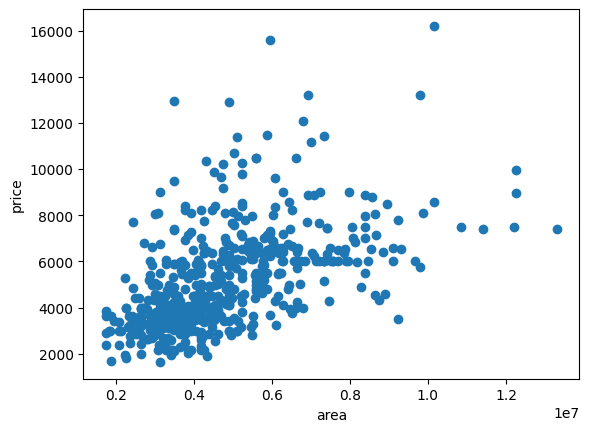

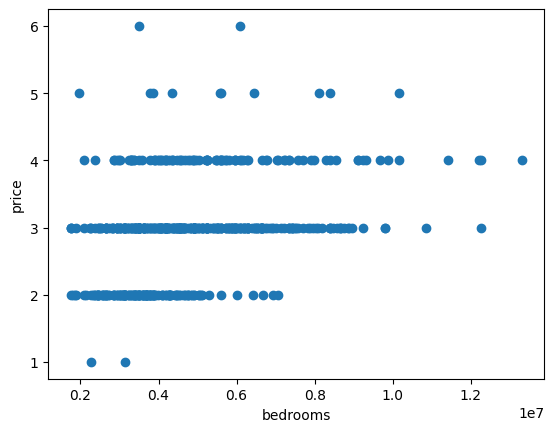

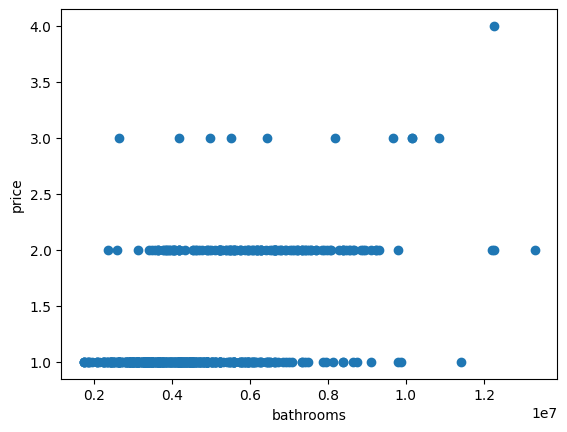

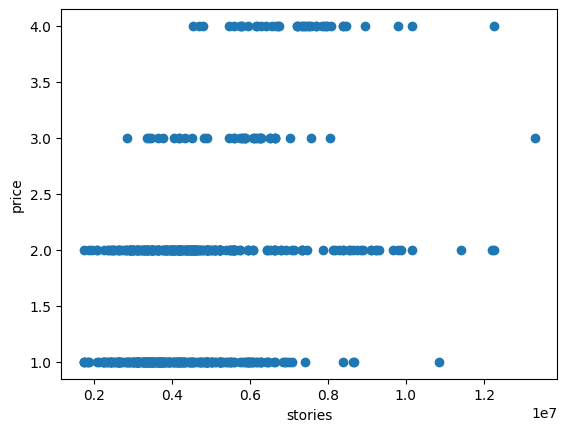

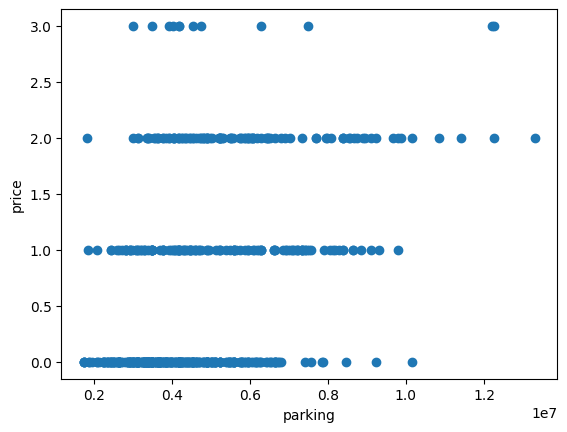

In [94]:
# this is for scatter plots
numerical_columns = df.select_dtypes(include=["int64", "float64"])
for col in numerical_columns:
    if col != "price":
        plt.scatter(df["price"], df[col])
        plt.xlabel(col)
        plt.ylabel("price")
        plt.show()

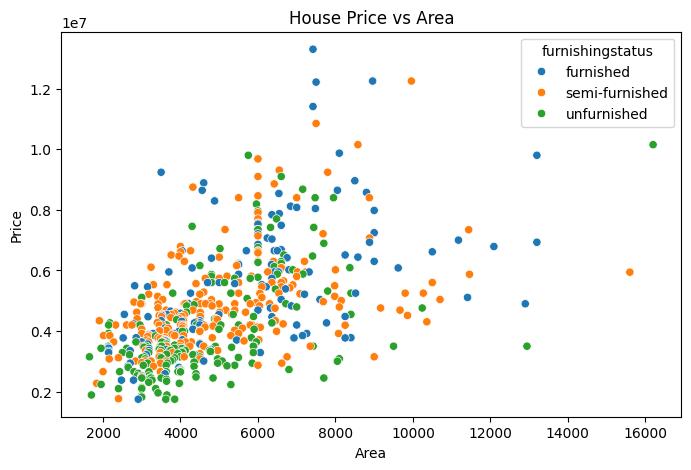

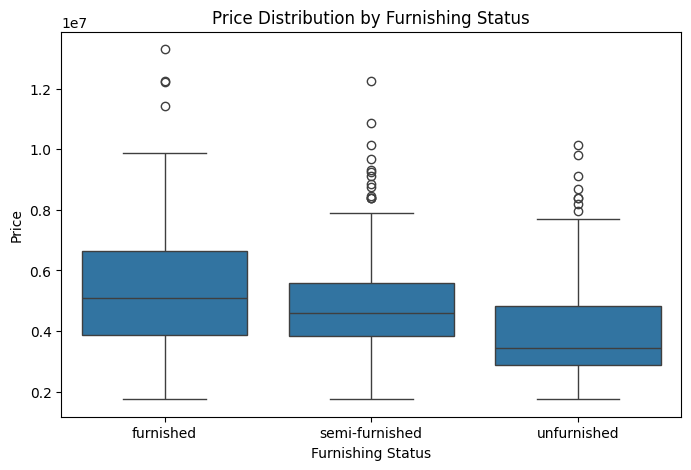

In [95]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="area", y="price", hue="furnishingstatus")
plt.title("House Price vs Area")
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="furnishingstatus", y="price")
plt.title("Price Distribution by Furnishing Status")
plt.xlabel("Furnishing Status")
plt.ylabel("Price")
plt.show()

# Preprocessing

Prepare the data for machine learning by handling categorical values, missing values, and feature scaling if needed.
Split the dataset into input features and target values, then create training and testing sets.

In [96]:
x = df.drop(columns = ["price"])#all features reside here
y = df["price"]#the outcome resides here
X_train , X_test , Y_train , Y_test = train_test_split(x,y , test_size=0.2,random_state = 42)#splitting the

In [97]:
numerical_columns = x.select_dtypes(include = ["integer" , "float64"]).columns#creating numerical columns
categorical_columns = x.select_dtypes(include = "object").columns#creating categorical columns

In [98]:
X_train , X_test , Y_train , Y_test = train_test_split(x,y , test_size=0.2,random_state = 42)

In [ ]:
#one hot encoding
preprocessor  = ColumnTransformer(transformers=[
    ("one_hot_encoding" , OneHotEncoder(sparse_output = False , handle_unknown= "ignore"), categorical_columns),
    ("StandardScaler" , StandardScaler() , numerical_columns)
])

In [ ]:
transformer2 = LinearRegression()#creating the object

# Training model

Train the machine learning model using the prepared training data.
This section fits the model so it can learn the relationship between house features and price.

# Evaluation

Evaluate the trained model using the test data and compare predicted prices with actual prices.
Use regression metrics such as MAE, MSE, RMSE, and R2 score to measure model performance.